In [72]:
print("hello world")

hello world


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
df = pd.read_csv("Bengaluru_House_Data.csv")

In [75]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [76]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [77]:
df.dropna(inplace = True)

In [78]:
df.duplicated().sum()

352

In [79]:
df.drop_duplicates(inplace = True)

In [80]:
df.dtypes

area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object

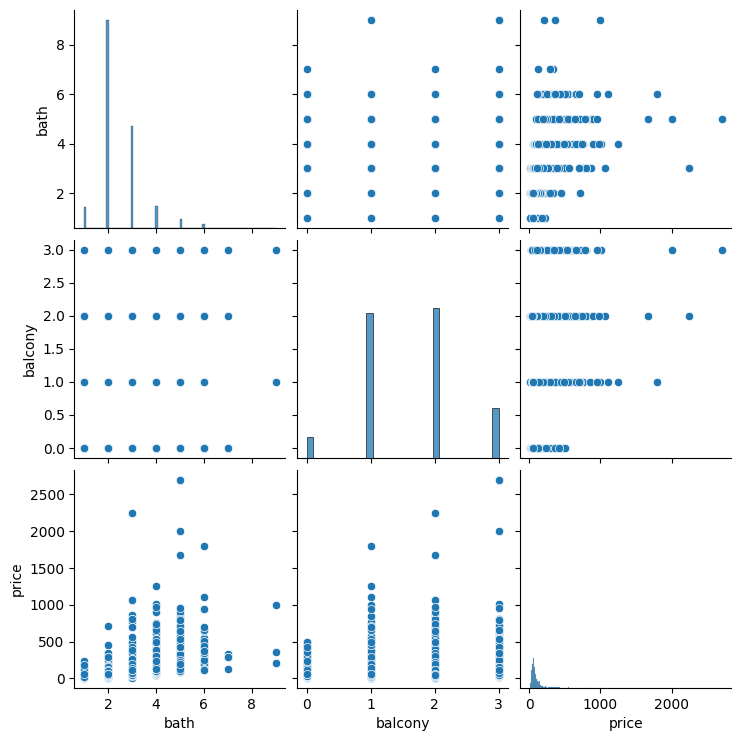

In [81]:
sns.pairplot(df)

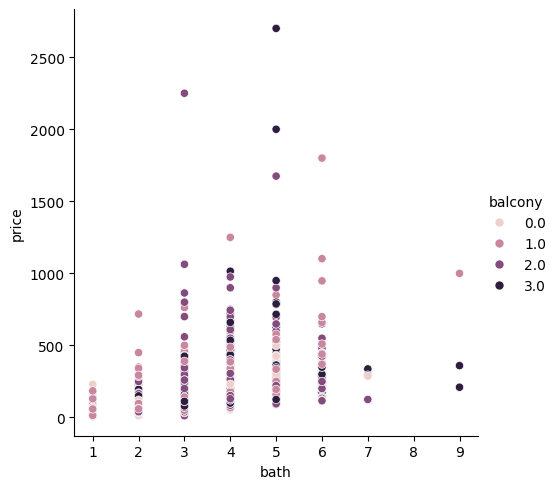

In [82]:
sns.relplot(x = 'bath' , y = "price" , data = df , hue = 'balcony')

In [83]:
# sns.catplot(x = 'society' , y = "size" , data = df)

In [84]:
cat_col = df.select_dtypes(include = "O")
num_col = df.select_dtypes(exclude = "O")

In [85]:
cat_col

,area_type,availability,location,size,society,total_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170
11,Plot Area,Ready To Move,Whitefield,4 Bedroom,Prrry M,2785
...,...,...,...,...,...,...
13308,Built-up Area,Ready To Move,Bannerghatta Road,3 BHK,Baanise,1527
13314,Super built-up Area,Ready To Move,Green Glen Layout,3 BHK,SoosePr,1715
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141


In [86]:
num_col

,bath,balcony,price
0,2.0,1.0,39.07
1,5.0,3.0,120.00
3,3.0,1.0,95.00
5,2.0,1.0,38.00
11,5.0,3.0,295.00
...,...,...,...
13308,3.0,1.0,142.00
13314,3.0,3.0,112.00
13315,4.0,0.0,231.00
13317,2.0,1.0,60.00


In [87]:
from sklearn.preprocessing import OrdinalEncoder

In [88]:
encoder = OrdinalEncoder()

In [89]:
encoder.fit(cat_col)

OrdinalEncoder()

In [90]:
transform_df = encoder.transform(cat_col)

In [91]:
num_col.shape

(7144, 3)

In [92]:
num_col.isnull().sum()

bath       0
balcony    0
price      0
dtype: int64

In [93]:
cat_col = pd.DataFrame(transform_df , columns = encoder.get_feature_names_out())

In [94]:
cat_col

,area_type,availability,location,size,society,total_sqft
0,3.0,35.0,210.0,3.0,443.0,63.0
1,2.0,73.0,149.0,8.0,2353.0,1128.0
2,3.0,73.0,387.0,5.0,2109.0,551.0
3,3.0,73.0,625.0,3.0,585.0,192.0
4,2.0,73.0,625.0,8.0,1566.0,1163.0
...,...,...,...,...,...,...
7139,0.0,73.0,91.0,5.0,262.0,557.0
7140,3.0,73.0,234.0,5.0,2148.0,725.0
7141,0.0,73.0,625.0,10.0,197.0,1262.0
7142,0.0,73.0,490.0,3.0,1168.0,159.0


In [95]:
cat_col.isnull().sum()

area_type       0
availability    0
location        0
size            0
society         0
total_sqft      0
dtype: int64

In [96]:
final_df = pd.concat([num_col,cat_col] , axis = 1)

In [97]:
final_df

,bath,balcony,price,area_type,availability,location,size,society,total_sqft
0,2.0,1.0,39.07,3.0,35.0,210.0,3.0,443.0,63.0
1,5.0,3.0,120.00,2.0,73.0,149.0,8.0,2353.0,1128.0
3,3.0,1.0,95.00,3.0,73.0,625.0,3.0,585.0,192.0
5,2.0,1.0,38.00,3.0,73.0,24.0,3.0,2015.0,0.0
11,5.0,3.0,295.00,3.0,35.0,119.0,5.0,1983.0,762.0
...,...,...,...,...,...,...,...,...,...
7133,NaN,NaN,NaN,3.0,73.0,521.0,7.0,1591.0,1080.0
7137,NaN,NaN,NaN,3.0,73.0,351.0,3.0,180.0,19.0
7139,NaN,NaN,NaN,0.0,73.0,91.0,5.0,262.0,557.0
7141,NaN,NaN,NaN,0.0,73.0,625.0,10.0,197.0,1262.0


In [98]:
final_df.isnull().sum()

bath            3266
balcony         3266
price           3266
area_type       3266
availability    3266
location        3266
size            3266
society         3266
total_sqft      3266
dtype: int64

In [99]:
final_df.dropna(inplace = True)

In [100]:
final_df

,bath,balcony,price,area_type,availability,location,size,society,total_sqft
0,2.0,1.0,39.07,3.0,35.0,210.0,3.0,443.0,63.0
1,5.0,3.0,120.00,2.0,73.0,149.0,8.0,2353.0,1128.0
3,3.0,1.0,95.00,3.0,73.0,625.0,3.0,585.0,192.0
5,2.0,1.0,38.00,3.0,73.0,24.0,3.0,2015.0,0.0
11,5.0,3.0,295.00,3.0,35.0,119.0,5.0,1983.0,762.0
...,...,...,...,...,...,...,...,...,...
7135,2.0,2.0,72.00,3.0,24.0,253.0,5.0,1795.0,806.0
7136,2.0,1.0,45.00,3.0,73.0,209.0,3.0,694.0,67.0
7138,2.0,0.0,130.00,3.0,73.0,490.0,3.0,777.0,211.0
7140,2.0,2.0,70.00,3.0,73.0,234.0,5.0,2148.0,725.0


In [101]:
x = final_df.drop('price' , axis = 1)

In [102]:
y = final_df[['price']]

In [103]:
x

,bath,balcony,area_type,availability,location,size,society,total_sqft
0,2.0,1.0,3.0,35.0,210.0,3.0,443.0,63.0
1,5.0,3.0,2.0,73.0,149.0,8.0,2353.0,1128.0
3,3.0,1.0,3.0,73.0,625.0,3.0,585.0,192.0
5,2.0,1.0,3.0,73.0,24.0,3.0,2015.0,0.0
11,5.0,3.0,3.0,35.0,119.0,5.0,1983.0,762.0
...,...,...,...,...,...,...,...,...
7135,2.0,2.0,3.0,24.0,253.0,5.0,1795.0,806.0
7136,2.0,1.0,3.0,73.0,209.0,3.0,694.0,67.0
7138,2.0,0.0,3.0,73.0,490.0,3.0,777.0,211.0
7140,2.0,2.0,3.0,73.0,234.0,5.0,2148.0,725.0


In [104]:
y

,price
0,39.07
1,120.00
3,95.00
5,38.00
11,295.00
...,...
7135,72.00
7136,45.00
7138,130.00
7140,70.00


In [105]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x, y , test_size = 0.2 , random_state = 42)

In [106]:
from sklearn.linear_model import LinearRegression , LogisticRegression
from sklearn.tree import DecisionTreeClassifier , DecisionTreeRegressor
from sklearn.svm import SVC , SVR

In [107]:

lr = LinearRegression()

In [108]:
lr.fit(x_train,y_train)

LinearRegression()

In [109]:
print(lr.score(x_test,y_test))

0.39499205010025473


In [110]:
# lgr.fit(x_train,y_train)

In [111]:
model = DecisionTreeRegressor(criterion = "squared_error" , max_depth = 3 , random_state = 42)

In [112]:
model.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [113]:
y_pred = model.predict(x_test)

In [114]:
from sklearn.metrics import accuracy_score

In [115]:
y_test.max()

price    1102.0
dtype: float64

In [116]:
y_pred.max()

468.2142857142857

In [117]:
from sklearn.metrics import mean_squared_error, r2_score
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

MSE: 6447.646463771651
R² Score: 0.4226123574098535


In [118]:
y_test = np.array(y_test)

In [119]:
y_test = y_test.ravel()  
y_pred = y_pred.ravel()

In [120]:
y_test = y_test.astype(int)  
y_pred = y_pred.astype(int)

In [121]:
print(y_test.dtype)
print(y_pred.dtype)

int32
int32


In [122]:
accuracy = accuracy_score(y_test,y_pred)

In [123]:
accuracy

0.011597938144329897

In [124]:
# svmmodel = SVR(kernel = "linear" , C = 1).fit(x_train,y_train)

In [125]:
# svmmodel.score(x_test,y_test)

In [126]:
# svmmodel.fit(x_train,y_train)

In [ ]:
# svmmodel.score(x_test,y_test)

0.3008998639528008

In [128]:
# from sklearn.linear_model import LinearRegression
lgr = LogisticRegression()

In [129]:
# x_train = np.array(x_train).ravel()
# y_train = np.array(y_train).ravel()

In [131]:
x_train=x_train.astype(int)

In [132]:
y_train=y_train.astype(int)

In [133]:
lgr.fit(x_train,y_train)

c:\Users\kumaw\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\kumaw\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [134]:
lgr.score(x_test,y_test)

0.028350515463917526

In [135]:
lgr.score(x_train,y_train)

0.03481624758220503

In [137]:
# from sklearn.preprocessing import StandardScaler
# import numpy as np

# # Sample data (3 samples, 2 features)
# X = np.array([[10, 200],
#               [20, 300],
#               [30, 400]])

# # Initialize the scaler
# scaler = StandardScaler()

# # Fit and transform the data
# X_scaled = scaler.fit_transform(X)

# print("Original Data:\n", X)
# print("Standardized Data:\n", X_scaled)
